In [29]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
import re

In [477]:
df_Q_US = pd.read_csv('Quarterly US GARCH MIDAS R v4.csv').drop_duplicates(subset = ['c.nm_var..nm_var..nm_var..nm_var..nm_var..nm_var.', 'model_diagnostics'])
df_Month_Sector = pd.read_csv('Monthly SECTOR GARCH MIDAS R v4.csv').drop_duplicates(subset = ['c.nm_var..nm_var..nm_var..nm_var..nm_var..nm_var.', 'model_diagnostics'])
df_Month_US = pd.read_csv('Monthly US GARCH MIDAS R v1.csv')
df_Q_Sector = pd.read_csv('Quarterly SECTOR GARCH MIDAS R v3.csv')

## GARCH Analysis Functions

In [ ]:
def Reformat_GARCH_Analysis(df : pd.DataFrame,
                            index_names = None,
                            col_names = None,
                            return_by_Indice = False):
    ''' 
    df <- do not parse anything or format anything
    MIDAS <- provide list of MIDAS variables in ORDER of how R does it
    returns <- provide list of returns in ORDER of how R does it
    '''
    if index_names is None:
        index_names = ['Alpha', 'Gamma', 'Beta', 'M', 'Theta', 'Weight']
        model_info_labels = [
            'Variance_Ratio', 'Total_Volatility', 'Long_Run_Volatility',
            'AIC', 'BIC', 'Log_Likelihood'
        ]
    if col_names is None:
        col_names = ['Parameter', 'Value', 'StD Error', 'T-Stat', 'Pr < |t|', 'Combination', 'Model Info']
    
    df.columns = col_names
    df.drop_duplicates(inplace = True)

    """
    Reformats a flat GARCH-MIDAS DataFrame into a multi-index panel-style DataFrame with the following structure:
    - MultiIndex [MIDAS Variable, Return, Section, Metric]
    - Columns for relevant values

    'Model Info' will have a 6-row entry for each combination under 'Metric' with 'Value' column
    'Parameter Info' will have 6 rows under 'Metric' (parameter names) and 3 columns:
        ['Value', 'StD Error', 'Pr < |t|']
    """
    df['Parameter'] = df['Parameter'].apply(lambda x: re.sub(r'\d+$', '', x))

    model_info_labels = [
        'Variance_Ratio', 'Total_Volatility', 'Long_Run_Volatility',
        'AIC', 'BIC', 'Log_Likelihood'
    ]

    panel_records = []

    for combo in df['Combination'].unique():
        sub_df = df[df['Combination'] == combo].copy().reset_index(drop=True)
        if len(sub_df) < 6:
            continue

        try:
            return_idx, midas_var = combo.split()
        except ValueError:
            continue

        for label, val in zip(model_info_labels, sub_df['Model Info'].values):
            panel_records.append([
                midas_var, return_idx, 'Model Info', label,
                val, None, None
            ])

        for _, row in sub_df.iterrows():
            param = row['Parameter']
            panel_records.append([
                midas_var, return_idx, 'Parameter Info', param,
                row['Value'], row['StD Error'], row['Pr < |t|']
            ])

    panel_df = pd.DataFrame(panel_records, columns=[
        'MIDAS Variable', 'Return', 'Section', 'Metric', 'Value', 'StD Error', 'Pr < |t|'
    ])
    panel_df.set_index(['MIDAS Variable', 'Return', 'Section', 'Metric'], inplace=True)

    return panel_df


In [405]:
def visualize_midas_performance(panel_df, top_n=10, drop = True):
    ''' 
    This function creates a visualisation based on the theta parameter results. Theta measures the
    degree of impact that the long run volatility component plays within the overall volatility
    forecast.

    The variance ratio is the variance of the log(long-term volatility 1-step ahead values) divided 
    by the variance of the log(total conditional volatility). A higher variance ratio indicates
    more of the asset/indice/security's volatility is attributed to the long-run component.

    This plots:
        - Y axis : Average variance ratio among the stocks which has it's 3 highest variance ratios
        - X axis : Average variance ratio among the stocks which it is statistically significant
        - Bubble Size : Number of stocks which has a statistically significant theta value
    '''
    if drop == True:
        panel_df.drop(panel_df.index[panel_df.index.get_level_values('MIDAS Variable') == 'EquityVol'], inplace = True)
        panel_df.drop(panel_df.index[panel_df.index.get_level_values('MIDAS Variable') == 'EquityVolMeasure'], inplace=True)
    # Separates the statistically significant thetas 
    theta_df = panel_df.xs('Parameter Info', level='Section')
    theta_df = theta_df.loc[theta_df.index.get_level_values('Metric') == 'theta']
    theta_df = theta_df.reset_index()
    theta_df = theta_df[theta_df['Pr < |t|'] < 0.05]
    
    # Number of Statistically significant indices
    sig_counts = theta_df.groupby('MIDAS Variable').size().reset_index(name='Significant_Count')

    avg_vr = (
        panel_df
        .xs(('Model Info', 'Variance_Ratio'), level=('Section', 'Metric'))['Value']
        .groupby('MIDAS Variable')
        .mean()
        .reset_index(name='Avg_VR')
    )

    vr_data = (
        panel_df
        .xs(('Model Info', 'Variance_Ratio'), level=('Section', 'Metric'))
        .reset_index()[['MIDAS Variable', 'Return', 'Value']]
    )

    top3_avg_vr = (
        theta_df[['MIDAS Variable', 'Return']]
        .drop_duplicates()
        .merge(vr_data, on=['MIDAS Variable', 'Return'])
        .sort_values(['MIDAS Variable', 'Value'], ascending=[True, False])
        .groupby('MIDAS Variable')
        .head(3)
        .groupby('MIDAS Variable')['Value']
        .mean()
        .reset_index(name='Top3_Avg_VR')
    )

    plot_df = sig_counts.merge(avg_vr, on='MIDAS Variable').merge(top3_avg_vr, on='MIDAS Variable')
    plot_df = plot_df.sort_values('Significant_Count', ascending=False).head(top_n)

    # Prepare plot
    plt.figure(figsize=(20,16))
    # Linear regression line
    x = plot_df['Avg_VR'].values
    y = plot_df['Top3_Avg_VR'].values
    slope, intercept = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept
    plt.plot(x_line, y_line, linestyle='--', color='grey', linewidth=2, label='Linear Fit')

    # Scatter bubble plot
    sns.scatterplot(
        data=plot_df,
        x='Avg_VR',
        y='Top3_Avg_VR',
        size='Significant_Count',
        hue='MIDAS Variable',
        sizes=(2000, 8000),
        alpha=0.7,
        edgecolor='black',
        linewidth=0.15,
        legend=False
    )

    # Annotations
    for _, row in plot_df.iterrows():
        plt.annotate(
            row['MIDAS Variable'],
            (row['Avg_VR'], row['Top3_Avg_VR']),
            fontsize=12, weight='bold', ha='center', va='center',
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6)
        )

    plt.title('MIDAS Variable Performance', fontsize=14)
    plt.xlabel('Average Variance Ratio', fontsize=12)
    plt.ylabel('Top 3 Significant Variance Ratio (Average)', fontsize=12)
    plt.tight_layout()
    plt.show()

    return plot_df

In [425]:
def plot_significant_counts_bar(panel_df):
    theta_df = panel_df.xs('Parameter Info', level='Section')
    theta_df = theta_df.loc[theta_df.index.get_level_values('Metric') == 'theta']
    theta_df = theta_df.reset_index()
    theta_df = theta_df[theta_df['Pr < |t|'] < 0.05]

    sig_counts = theta_df.groupby('MIDAS Variable').size().reset_index(name='Significant_Count')

    plt.figure(figsize=(12, 6))
    sns.barplot(data=sig_counts, x='MIDAS Variable', y='Significant_Count')
    plt.title('Number of Statistically Significant Theta Parameters by MIDAS Variable')
    plt.xticks(rotation=45)
    plt.grid(True, axis='y')
    plt.tight_layout()
    plt.show()

    return sig_counts


def plot_average_weights(panel_df, ax, frequency = 'Quarterly', threshold=0.1):

    # Get the rows where theta is greater than 0.1 
    theta_df = panel_df.xs('Parameter Info', level='Section')
    theta_df = theta_df.loc[theta_df.index.get_level_values('Metric') == 'theta']
    filtered_by_theta = theta_df[np.abs(theta_df['Value']) > threshold]

    # Extract the weights corresponding to the filtered theta values
    weights_df = panel_df.xs('Parameter Info', level='Section')
    weights_df = weights_df.loc[weights_df.index.get_level_values('Metric') == 'w']
    
    # Simplify the multi level index => (MIDAS Variable, Return, Parameter, Value)
    valid_combinations = filtered_by_theta.index.droplevel(['MIDAS Variable', 'Metric'])

    # Select based on the valid combos
    filtered = weights_df[weights_df.index.droplevel(['MIDAS Variable', 'Metric']).isin(valid_combinations)]

    avg_weights = filtered.groupby('MIDAS Variable')['Value'].mean().reset_index(name='Average_Weight')
    median_weights = filtered.groupby('MIDAS Variable')['Value'].median().reset_index(name='Median_Weight')

    temp_df = pd.concat([avg_weights, median_weights], axis=1)
    temp_df = temp_df.loc[:,~temp_df.columns.duplicated(keep='first')].copy()

    temp_df.set_index('MIDAS Variable', inplace=True)
    temp_df.columns = ['Average_Weight', 'Median_Weight']
    temp_df.index.name = 'MIDAS Variable'
    
    temp_df.plot.bar(rot = 30,
                     ax = ax,
                     legend = True,
                     color = ['darkgreen', 'crimson'])
    ax.set_title(f'Average and Median MIDAS Weights with {threshold} theta threshold')
    ax.set_ylabel(f'Periods {frequency}')
    ax.set_xlabel('MIDAS Variable')
    ax.set_xticklabels(temp_df.index, rotation=45, ha='right')
    
    return avg_weights, median_weights



In [484]:
def plot_return_level_stats(panel_df, threshold=0.05):
    """
    Plots, for each Return, the number of MIDAS variables with statistically significant theta (Pr < |t| < threshold)
    and the average variance ratio of those significant variables.

    Parameters:
    - panel_df: MultiIndex DataFrame with levels [MIDAS Variable, Return, Section, Metric]
    - threshold: float, significance cutoff for theta's 'Pr < |t|' value

    Returns:
    - stats_df: DataFrame with columns ['Return', 'Significant_Count', 'Avg_VR']
    """
    # Extract theta parameter rows and filter by significance
    theta_df = panel_df.xs('Parameter Info', level='Section')
    theta_df = theta_df[theta_df.index.get_level_values('Metric') == 'theta']
    theta_df = theta_df.reset_index()
    sig = theta_df[theta_df['Pr < |t|'] < threshold]

    # Count of significant MIDAS variables per Return
    combos = sig[['MIDAS Variable', 'Return']].drop_duplicates()
    sig_counts = combos.groupby('Return').size().reset_index(name='Significant_Count')

    # Extract variance ratio model info
    vr = panel_df.xs(('Model Info', 'Variance_Ratio'), level=('Section', 'Metric'))['Value']
    vr = vr.reset_index()[['MIDAS Variable', 'Return', 'Value']]

    # Compute average variance ratio for significant combos per Return
    merged = combos.merge(vr, on=['MIDAS Variable', 'Return'])
    avg_vr = merged.groupby('Return')['Value'].mean().reset_index(name='Avg_VR')

    # Combine counts and averages
    stats_df = sig_counts.merge(avg_vr, on='Return')

    # Plotting
    fig, ax1 = plt.subplots(figsize=(12, 6))
    sns.barplot(
        data=stats_df,
        x='Return',
        y='Significant_Count',
        color='skyblue',
        ax=ax1
    )
    ax1.set_xlabel('Return')
    ax1.set_ylabel('Significant MIDAS Count', color='skyblue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)

    ax2 = ax1.twinx()
    sns.lineplot(
        data=stats_df,
        x='Return',
        y='Avg_VR',
        marker='o',
        color='darkorange',
        ax=ax2
    )
    ax2.set_ylabel('Average Variance Ratio', color='darkorange')
    ax2.tick_params(axis='y', labelcolor='darkorange')

    plt.title(f'Return-level Stats (theta threshold = {threshold})')
    fig.tight_layout()
    plt.show()

    return stats_df

In [502]:
def plot_midas_vr_per_return(panel_df, vr_threshold, max_vars=3, chunk_size=9):
    """
    For each chunk of returns, plots grouped bar charts of MIDAS variables
    with Variance_Ratio above vr_threshold.

    - x-axis: MIDAS Variable labels
    - bars side-by-side showing Variance_Ratio
    - top max_vars variables per return
    - subplots stacked (chunk_size per figure)

    Parameters:
    - panel_df: MultiIndex DataFrame [MIDAS Variable, Return, Section, Metric]
    - vr_threshold: float, include only Variance_Ratio > vr_threshold
    - max_vars: int, max MIDAS variables per return
    - chunk_size: int, number of returns per figure
    """
    # Extract VR
    vr_df = panel_df.xs(('Model Info', 'Variance_Ratio'), level=('Section', 'Metric'))['Value'].reset_index()
    returns = vr_df['Return'].unique().tolist()

    # Split into chunks
    for i in range(0, len(returns), chunk_size):
        chunk = returns[i:i+chunk_size]
        n = len(chunk)
        fig, axes = plt.subplots(n, 1, figsize=(12, 6*n), sharex=False)
        if n == 1:
            axes = [axes]

        for ax, ret in zip(axes, chunk):
            sub = vr_df[(vr_df['Return'] == ret) & (vr_df['Value'] > vr_threshold)].copy()
            sub = sub.sort_values('Value', ascending=False).head(max_vars)

            if sub.empty:
                ax.text(0.5, 0.5, f'No vars > {vr_threshold}', ha='center', va='center')
                ax.set_title(f'{ret}')
                ax.set_ylabel('Variance Ratio')
                continue

            # Plot bars manually for side-by-side
            x = np.arange(len(sub))
            bars = ax.bar(x, sub['Value'], width=0.4, color='skyblue', edgecolor='black')

            # Annotate with MIDAS Variable labels
            for xi, height, lbl in zip(x, sub['Value'], sub['MIDAS Variable']):
                ax.text(xi, height + 0.005 * sub['Value'].max(), lbl,
                        ha='center', va='bottom', fontsize=9, rotation=0)

            ax.set_title(f'MIDAS VAR > {vr_threshold} for {ret}')
            ax.set_ylabel('Variance Ratio')
            ax.set_xticks(x)
            ax.set_xticklabels([ret] * len(sub), rotation=0)

        plt.tight_layout()
        plt.show()

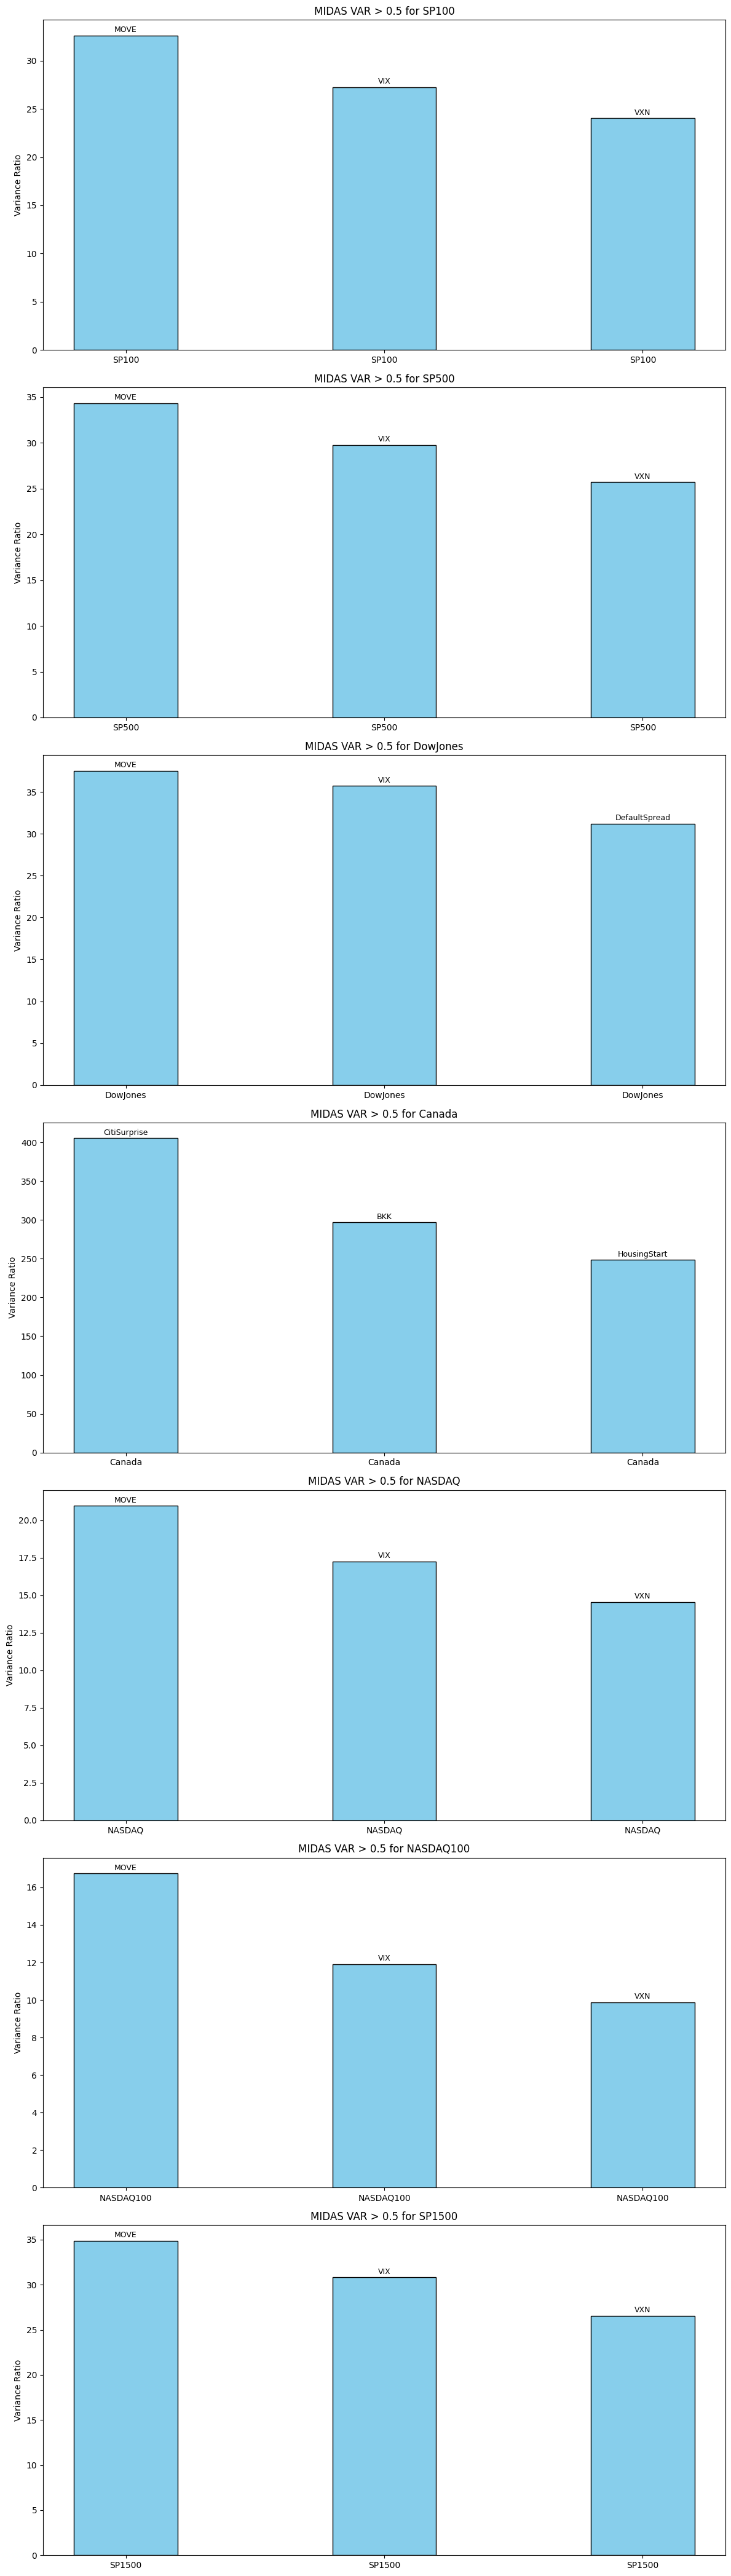

In [503]:
plot_midas_vr_per_return(df, vr_threshold=0.5)

## GARCH Analysis

### Quarterly US Indices

In [478]:
df = Reformat_GARCH_Analysis(df_Q_US)

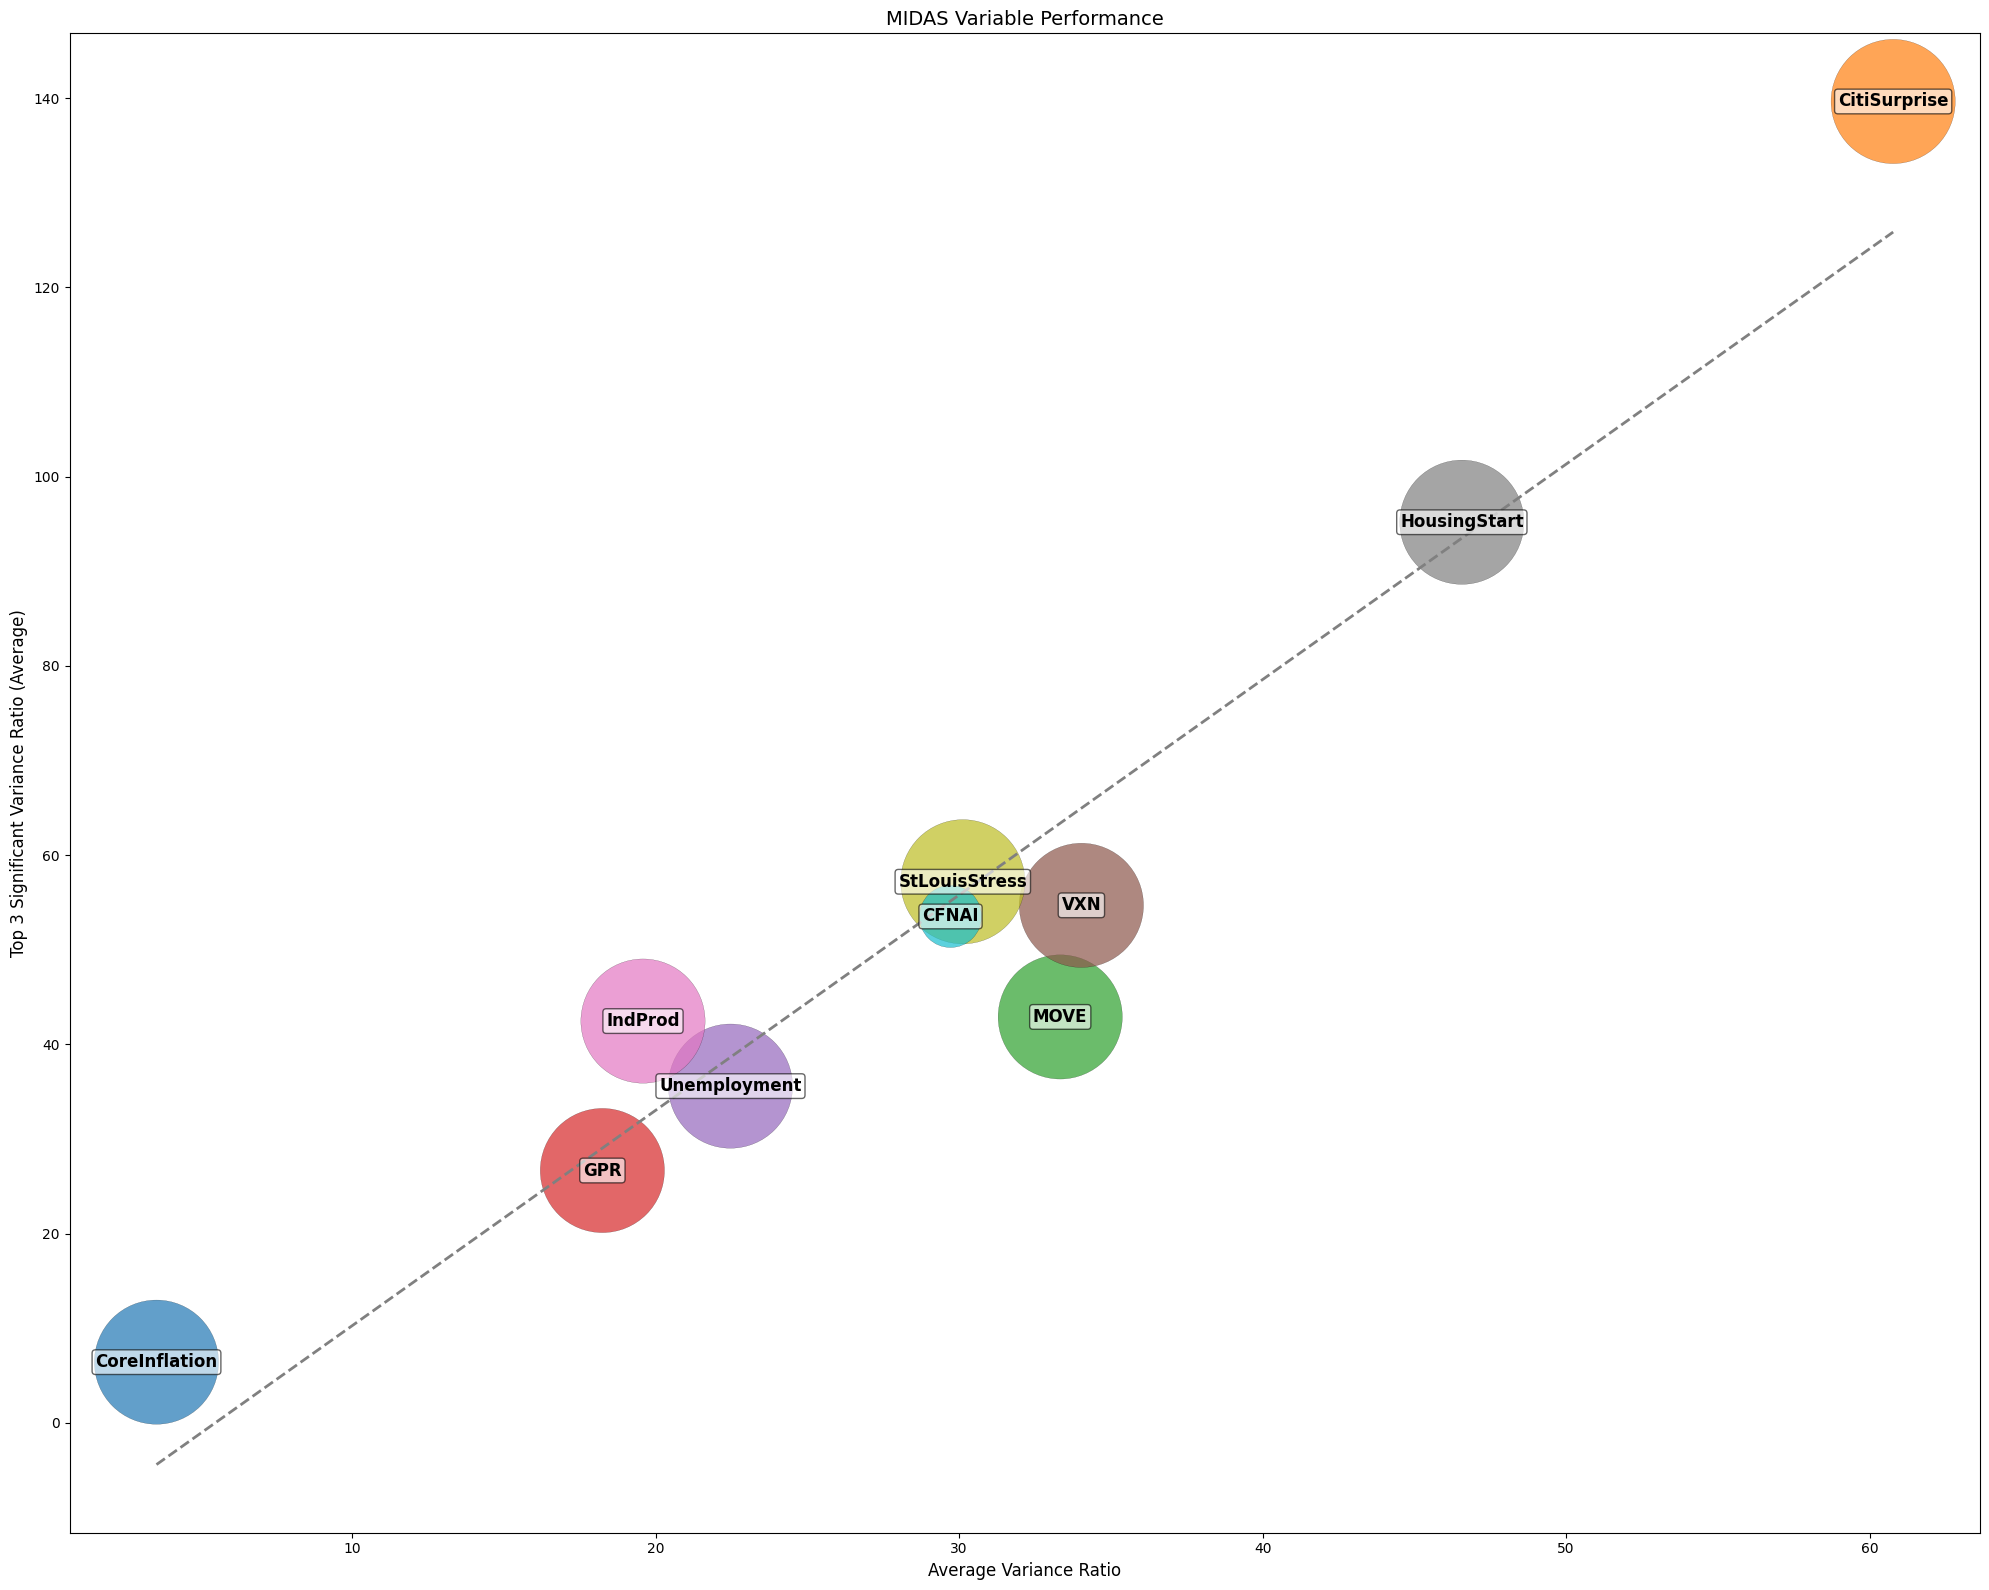

,MIDAS Variable,Significant_Count,Avg_VR,Top3_Avg_VR
3,CoreInflation,8,3.558563,6.403552
2,CitiSurprise,8,60.772954,139.641365
10,MOVE,8,33.332388,42.889829
7,GPR,8,18.248129,26.657272
17,Unemployment,8,22.468604,35.576751
19,VXN,8,34.029511,54.683206
9,IndProd,8,19.586445,42.451125
8,HousingStart,8,46.562852,95.173110
14,StLouisStress,8,30.122343,57.177056
1,CFNAI,7,29.718004,53.506685


In [479]:
visualize_midas_performance(df)

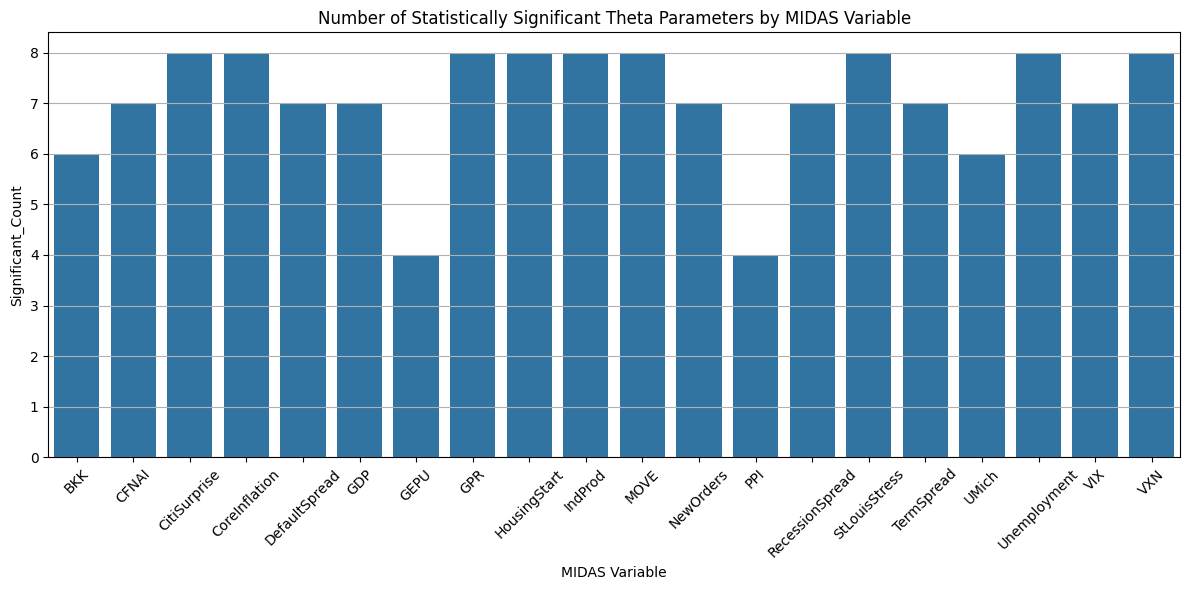

,MIDAS Variable,Significant_Count
0,BKK,6
1,CFNAI,7
2,CitiSurprise,8
3,CoreInflation,8
4,DefaultSpread,7
5,GDP,7
6,GEPU,4
7,GPR,8
8,HousingStart,8
9,IndProd,8


In [480]:
plot_significant_counts_bar(df)

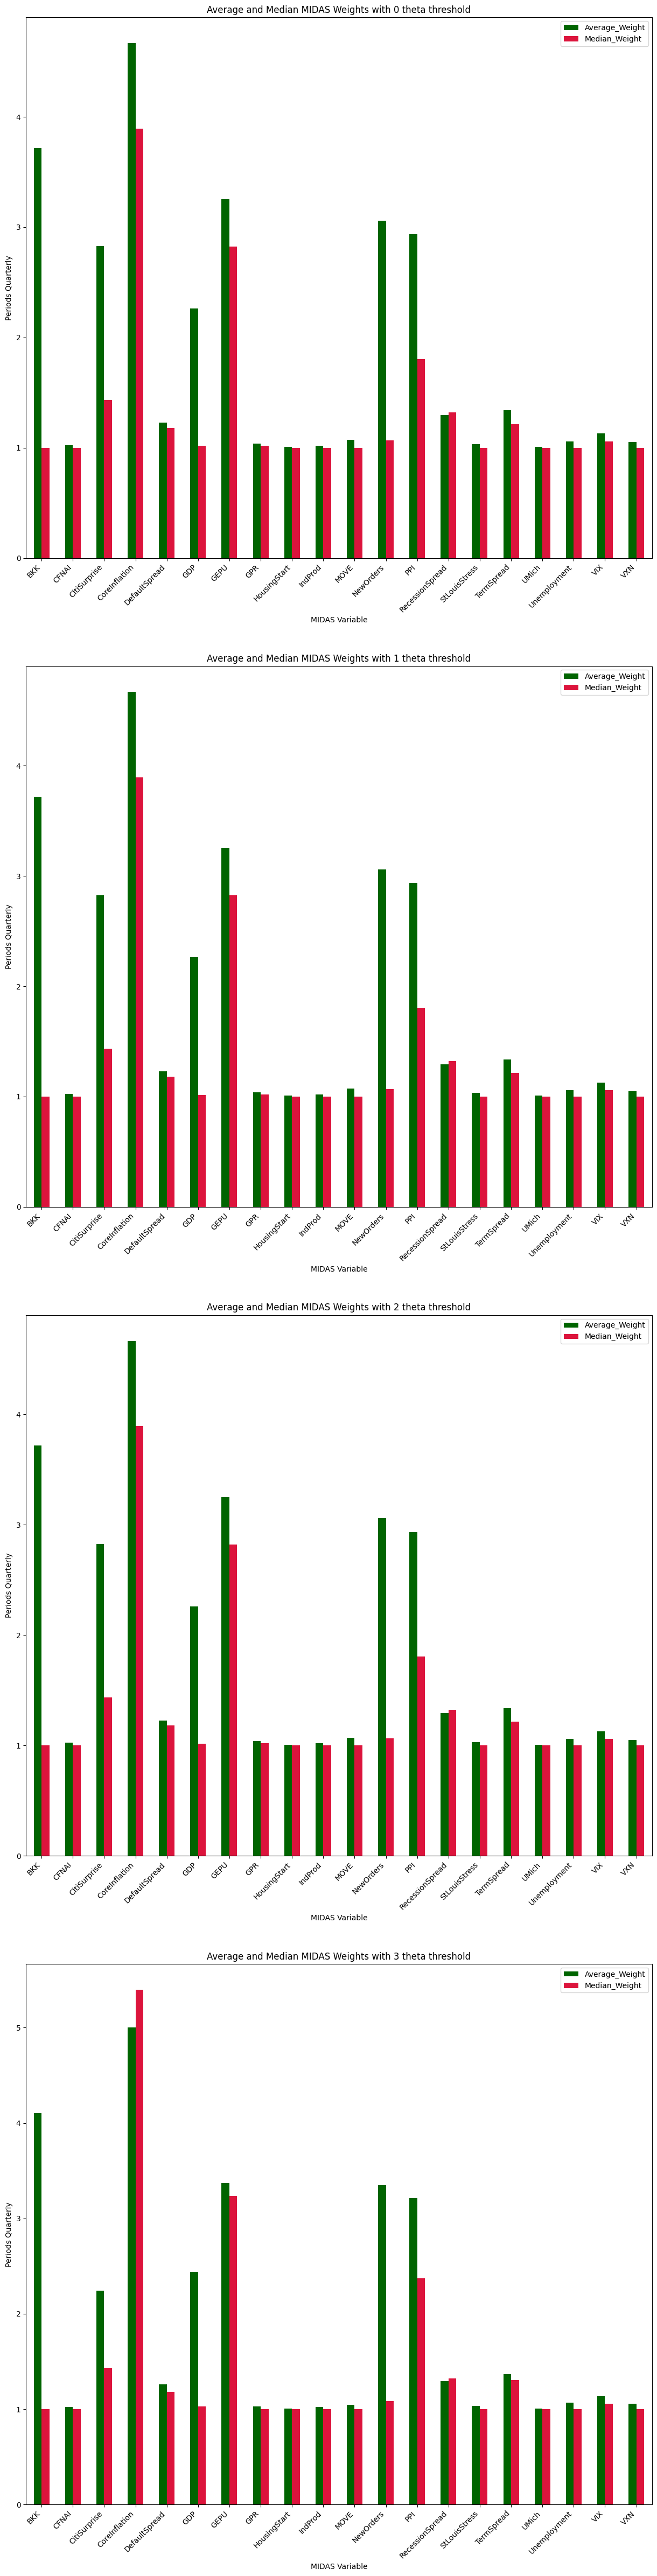

In [481]:
fig, axs = plt.subplots(4, 1, figsize = (15, 60))
thresholds = np.arange(0, 4, 1)
axes = axs.flatten()

for count, threshold in enumerate(thresholds):
    plot_average_weights(df, axes[count], threshold = threshold, frequency = 'Quarterly')


C:\Users\Phillip\AppData\Local\Temp\ipykernel_11084\1130741609.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)


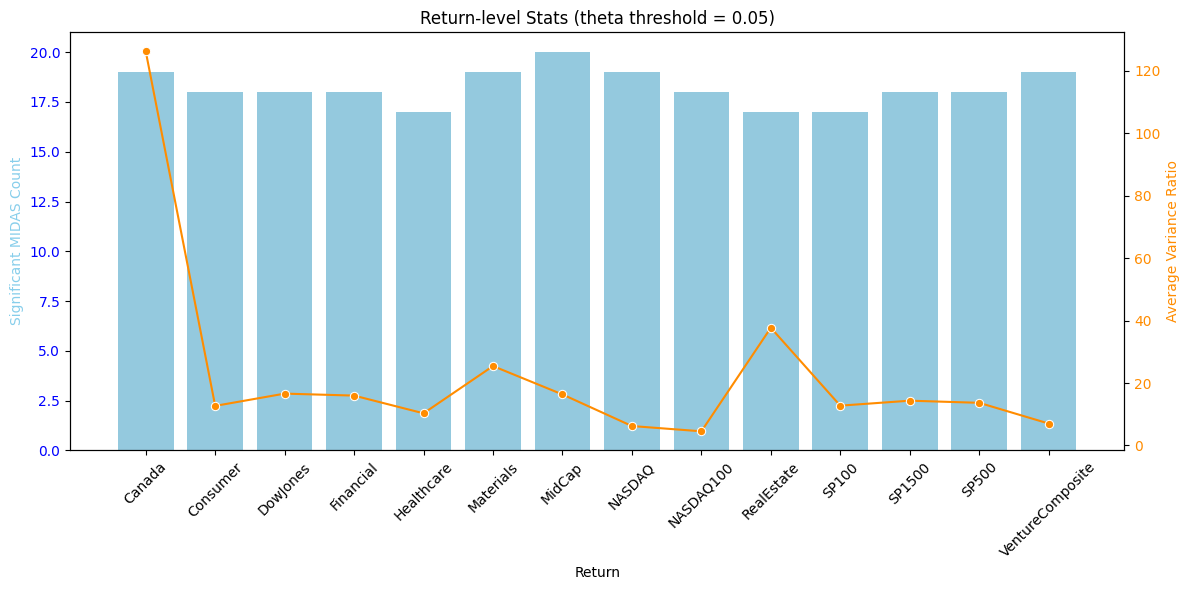

,Return,Significant_Count,Avg_VR
0,Canada,19,126.237382
1,Consumer,18,12.674822
2,DowJones,18,16.604811
3,Financial,18,15.970667
4,Healthcare,17,10.294830
5,Materials,19,25.433132
6,MidCap,20,16.341307
7,NASDAQ,19,6.219743
8,NASDAQ100,18,4.530135
9,RealEstate,17,37.695704


In [473]:
plot_return_level_stats(df)

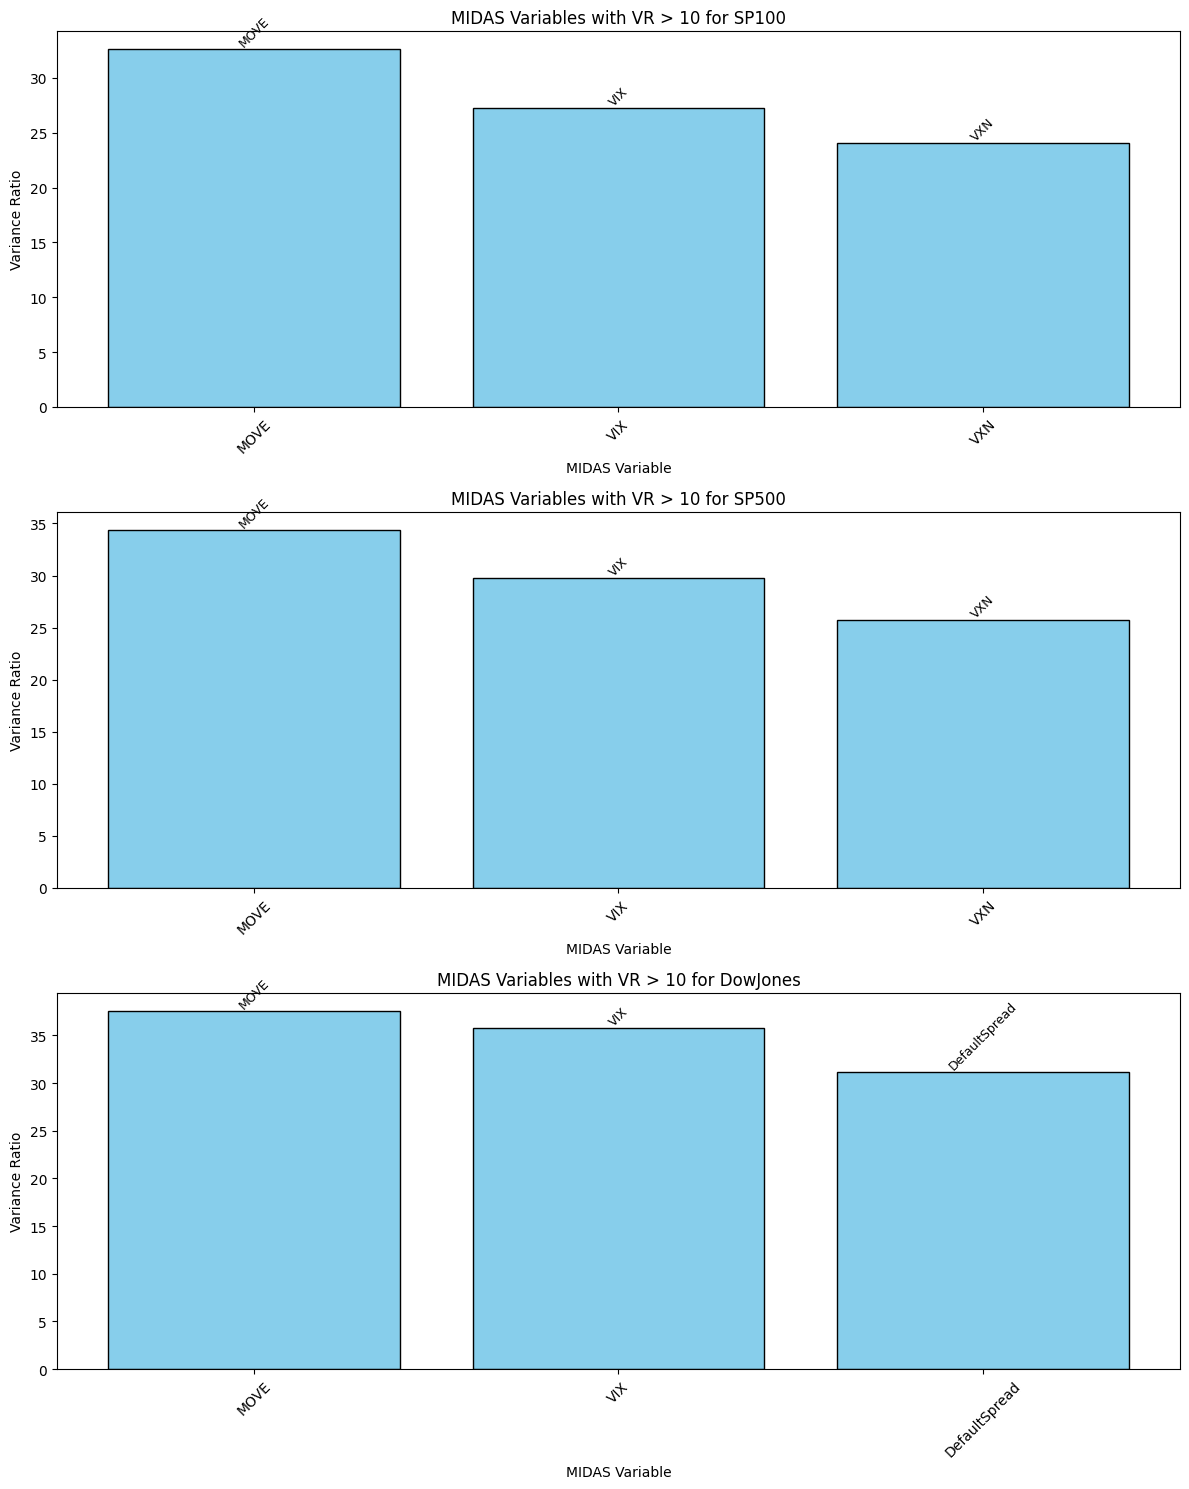

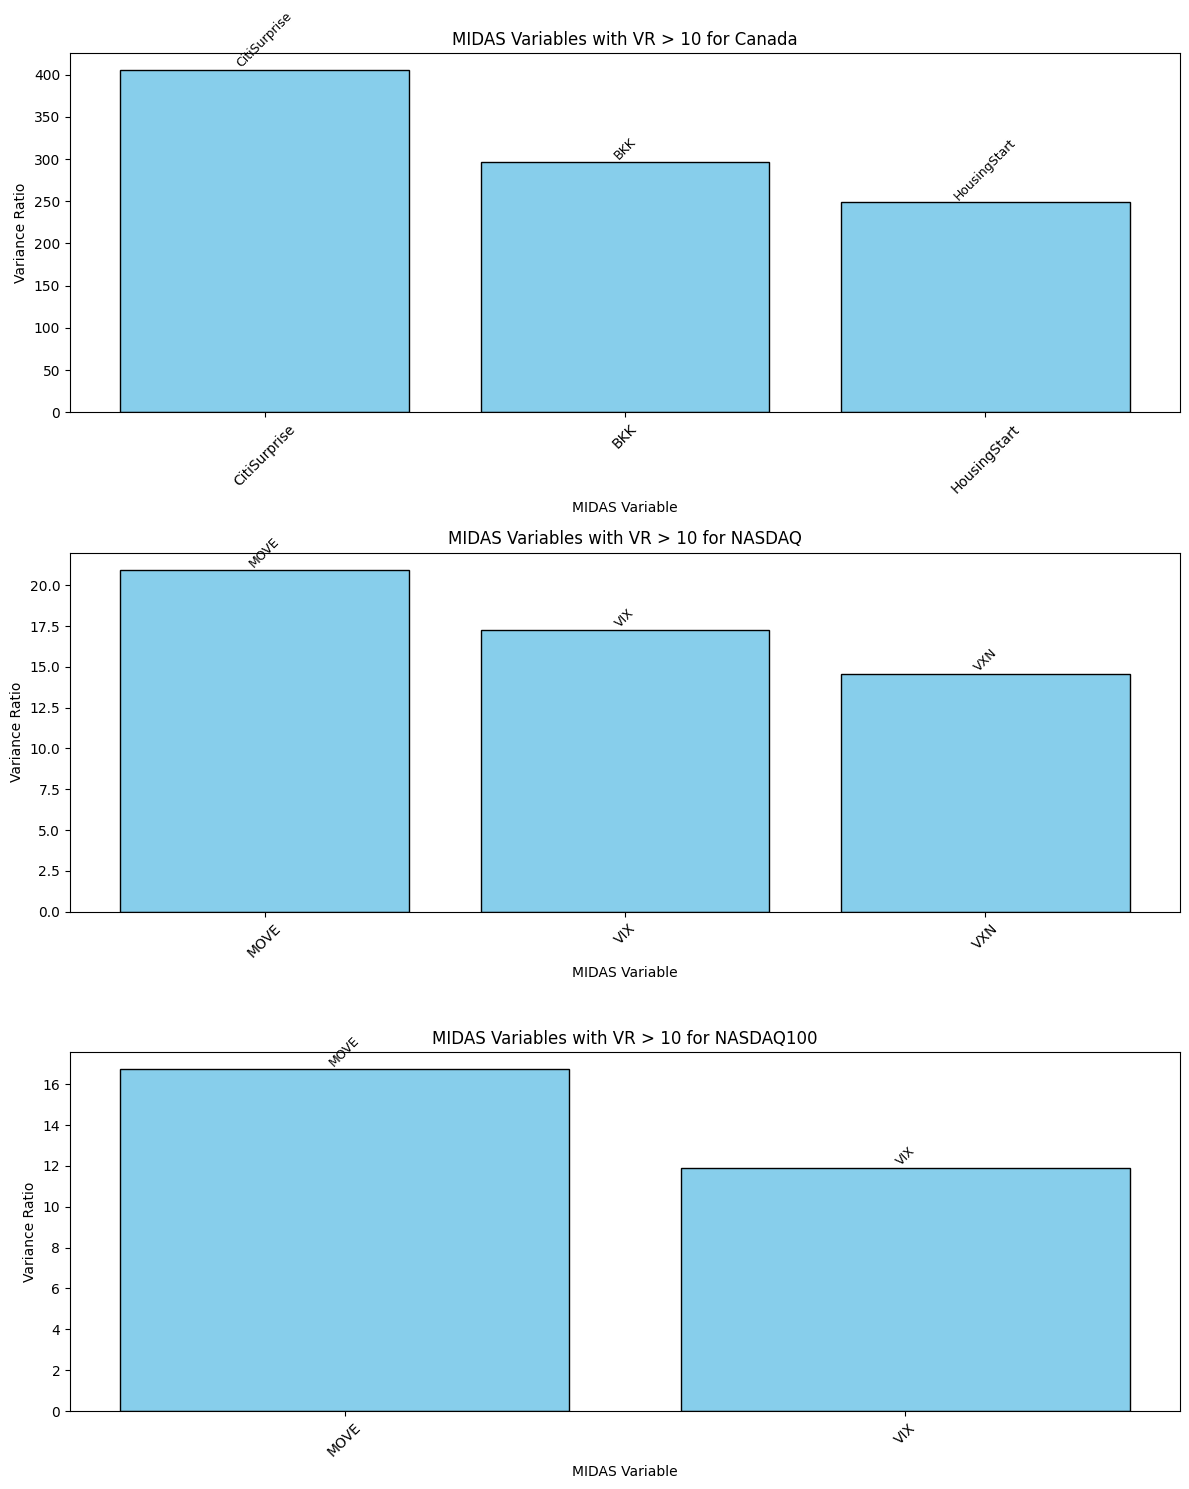

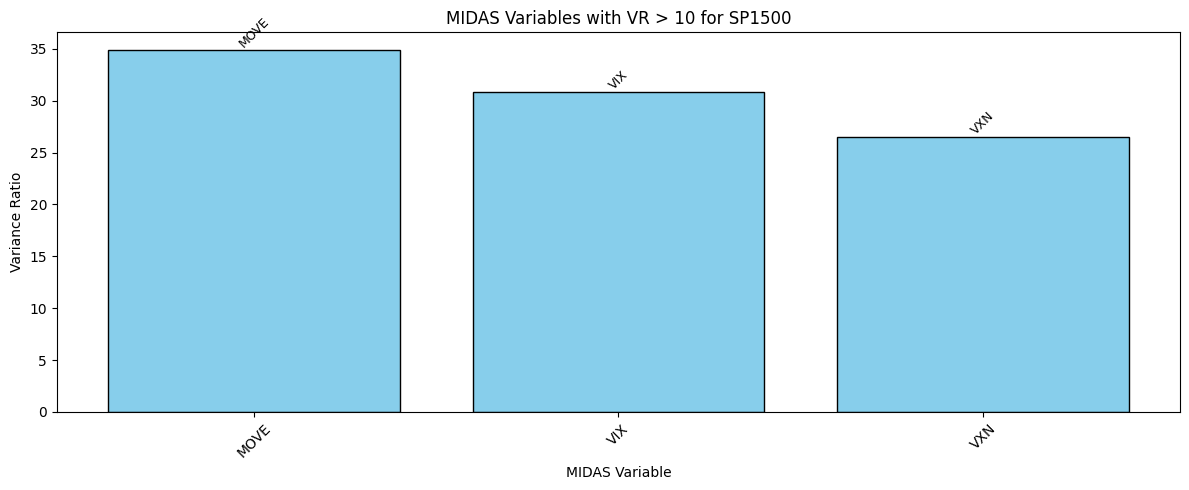

In [486]:
plot_midas_vr_per_return(df, 10, 3, 3)

### Quarterly Sector Indices

In [ ]:
df_Q_Sector_formatted = Reformat_GARCH_Analysis(df_Q_Sector)

Did not include equity volatility measure, as it is a combination of realized volatility and VIX (contigent on the S&P 500) - which has already been well established to show explanatory significance.

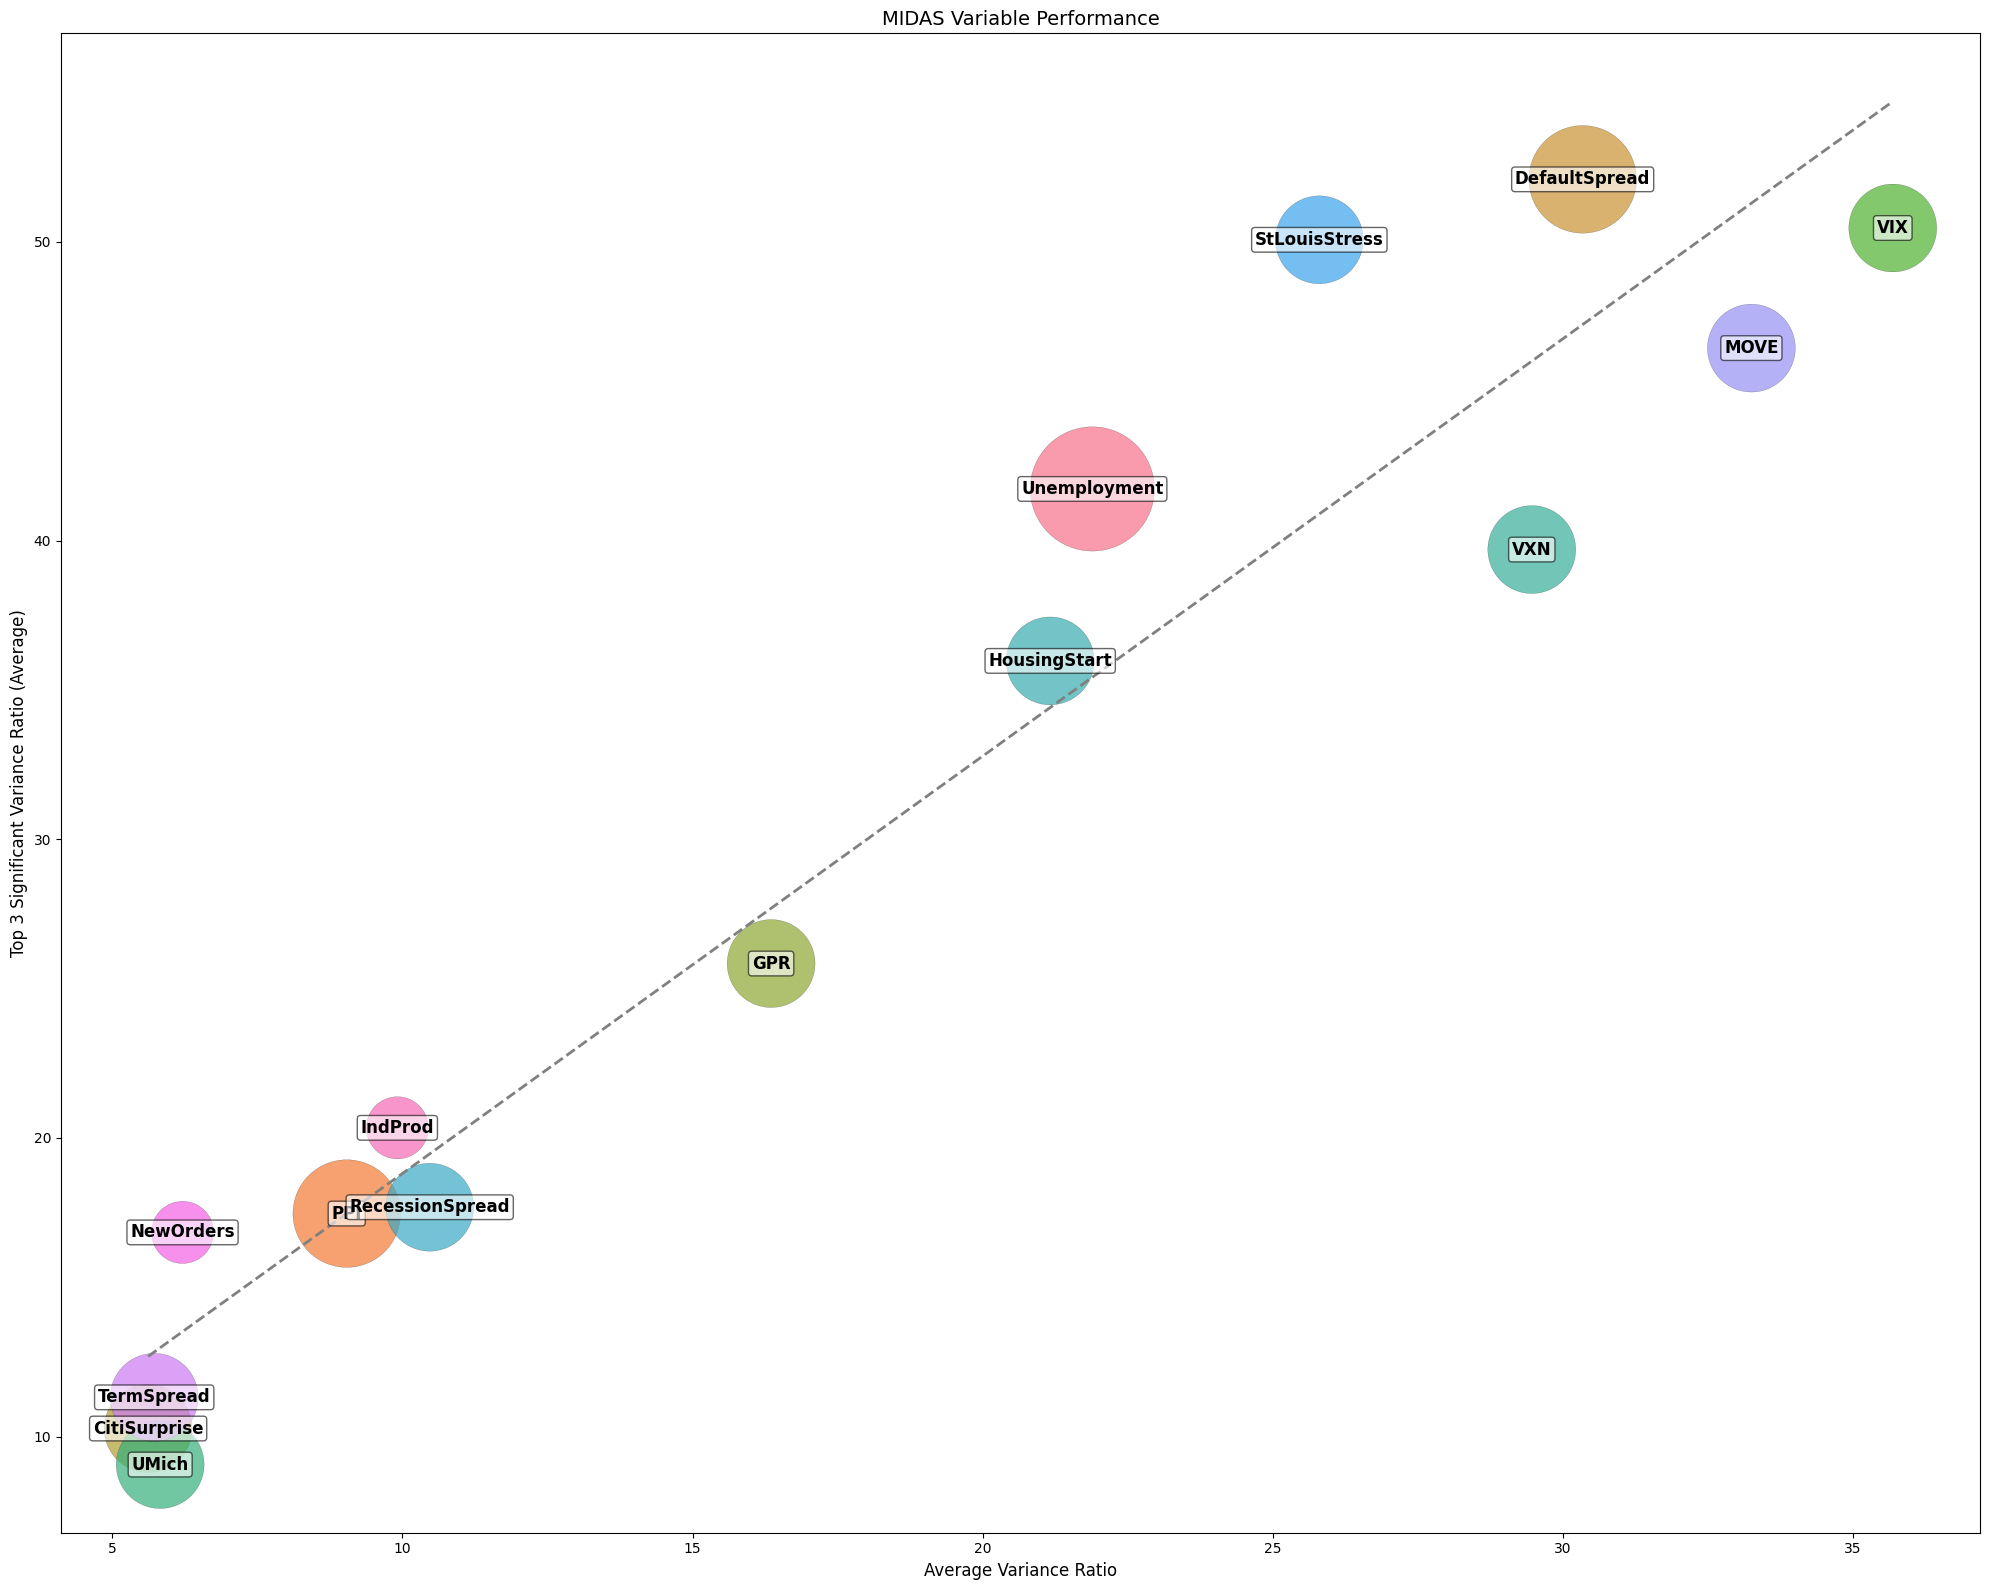

,MIDAS Variable,Significant_Count,Avg_VR,Top3_Avg_VR
18,Unemployment,12,21.891429,41.730462
13,PPI,11,9.040148,17.466207
4,DefaultSpread,11,30.343162,52.097600
2,CitiSurprise,10,5.616915,10.267964
8,GPR,10,16.354888,25.838830
19,VIX,10,35.687813,50.468098
17,UMich,10,5.824512,9.061185
20,VXN,10,29.465809,39.700793
9,HousingStart,10,21.164888,35.972419
14,RecessionSpread,10,10.470266,17.678302


In [411]:
visualize_midas_performance(df_Q_Sector_formatted, top_n = 15, drop = False)

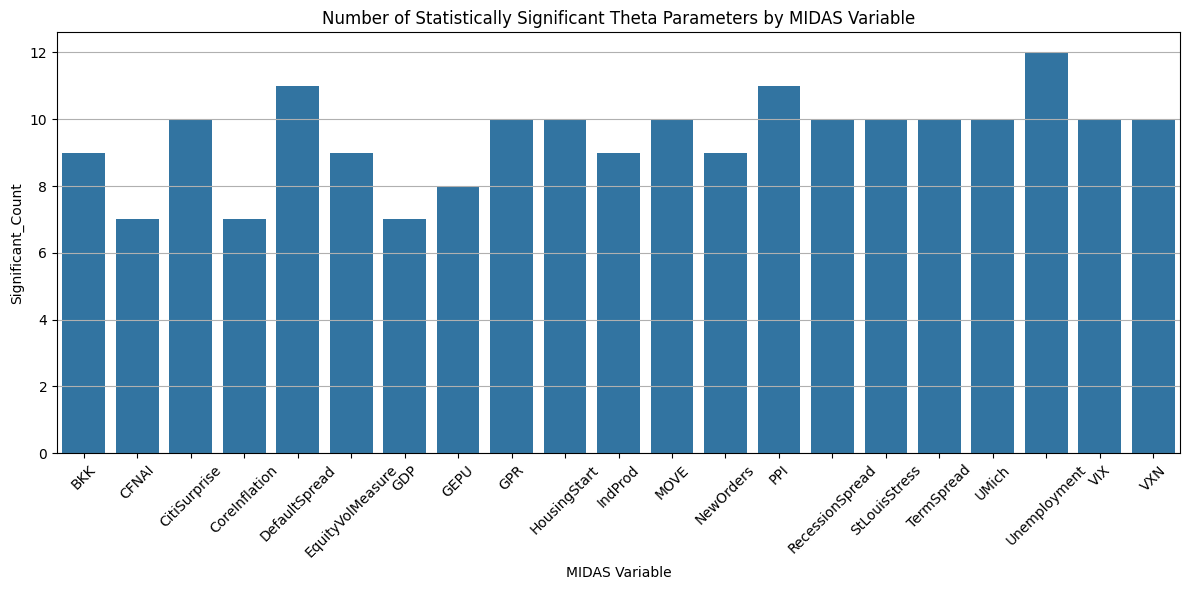

,MIDAS Variable,Significant_Count
0,BKK,9
1,CFNAI,7
2,CitiSurprise,10
3,CoreInflation,7
4,DefaultSpread,11
5,EquityVolMeasure,9
6,GDP,7
7,GEPU,8
8,GPR,10
9,HousingStart,10


In [413]:
plot_significant_counts_bar(df_Q_Sector_formatted)

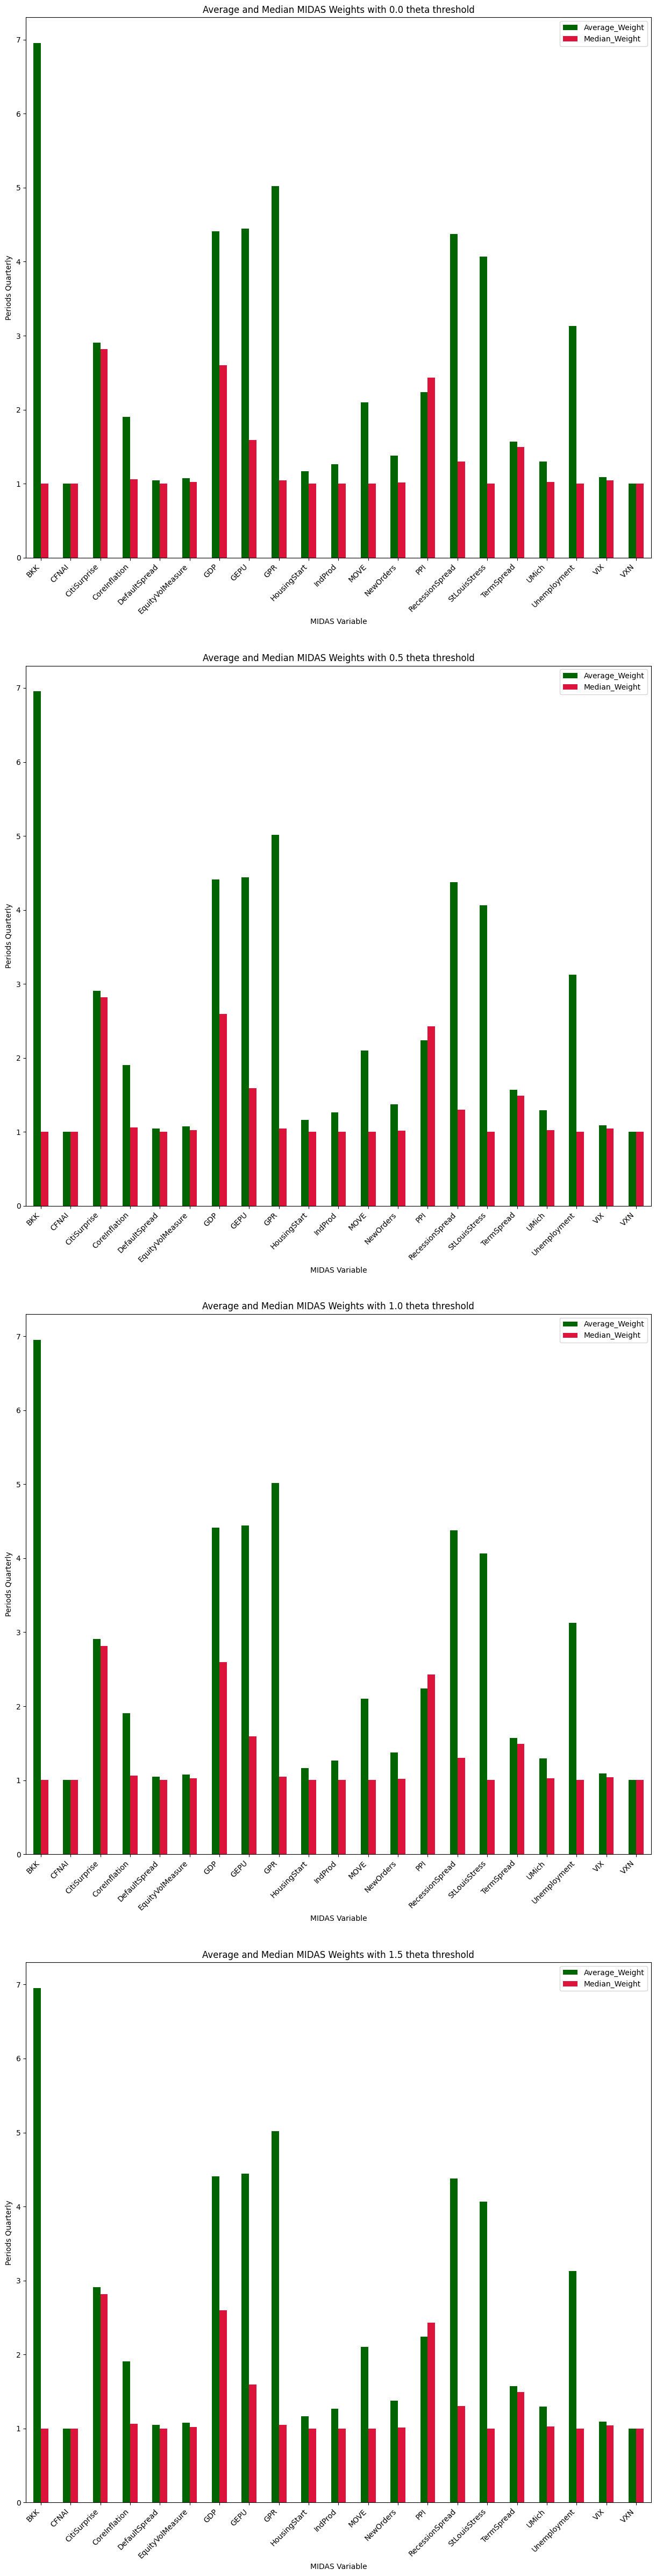

In [414]:
fig, axs = plt.subplots(4, 1, figsize = (15, 60))
thresholds = np.arange(0, 2, 0.5)
axes = axs.flatten()

for count, threshold in enumerate(thresholds):
    plot_average_weights(df_Q_Sector_formatted, axes[count], threshold = threshold, frequency = 'Quarterly')


### Monthly Sector Indices

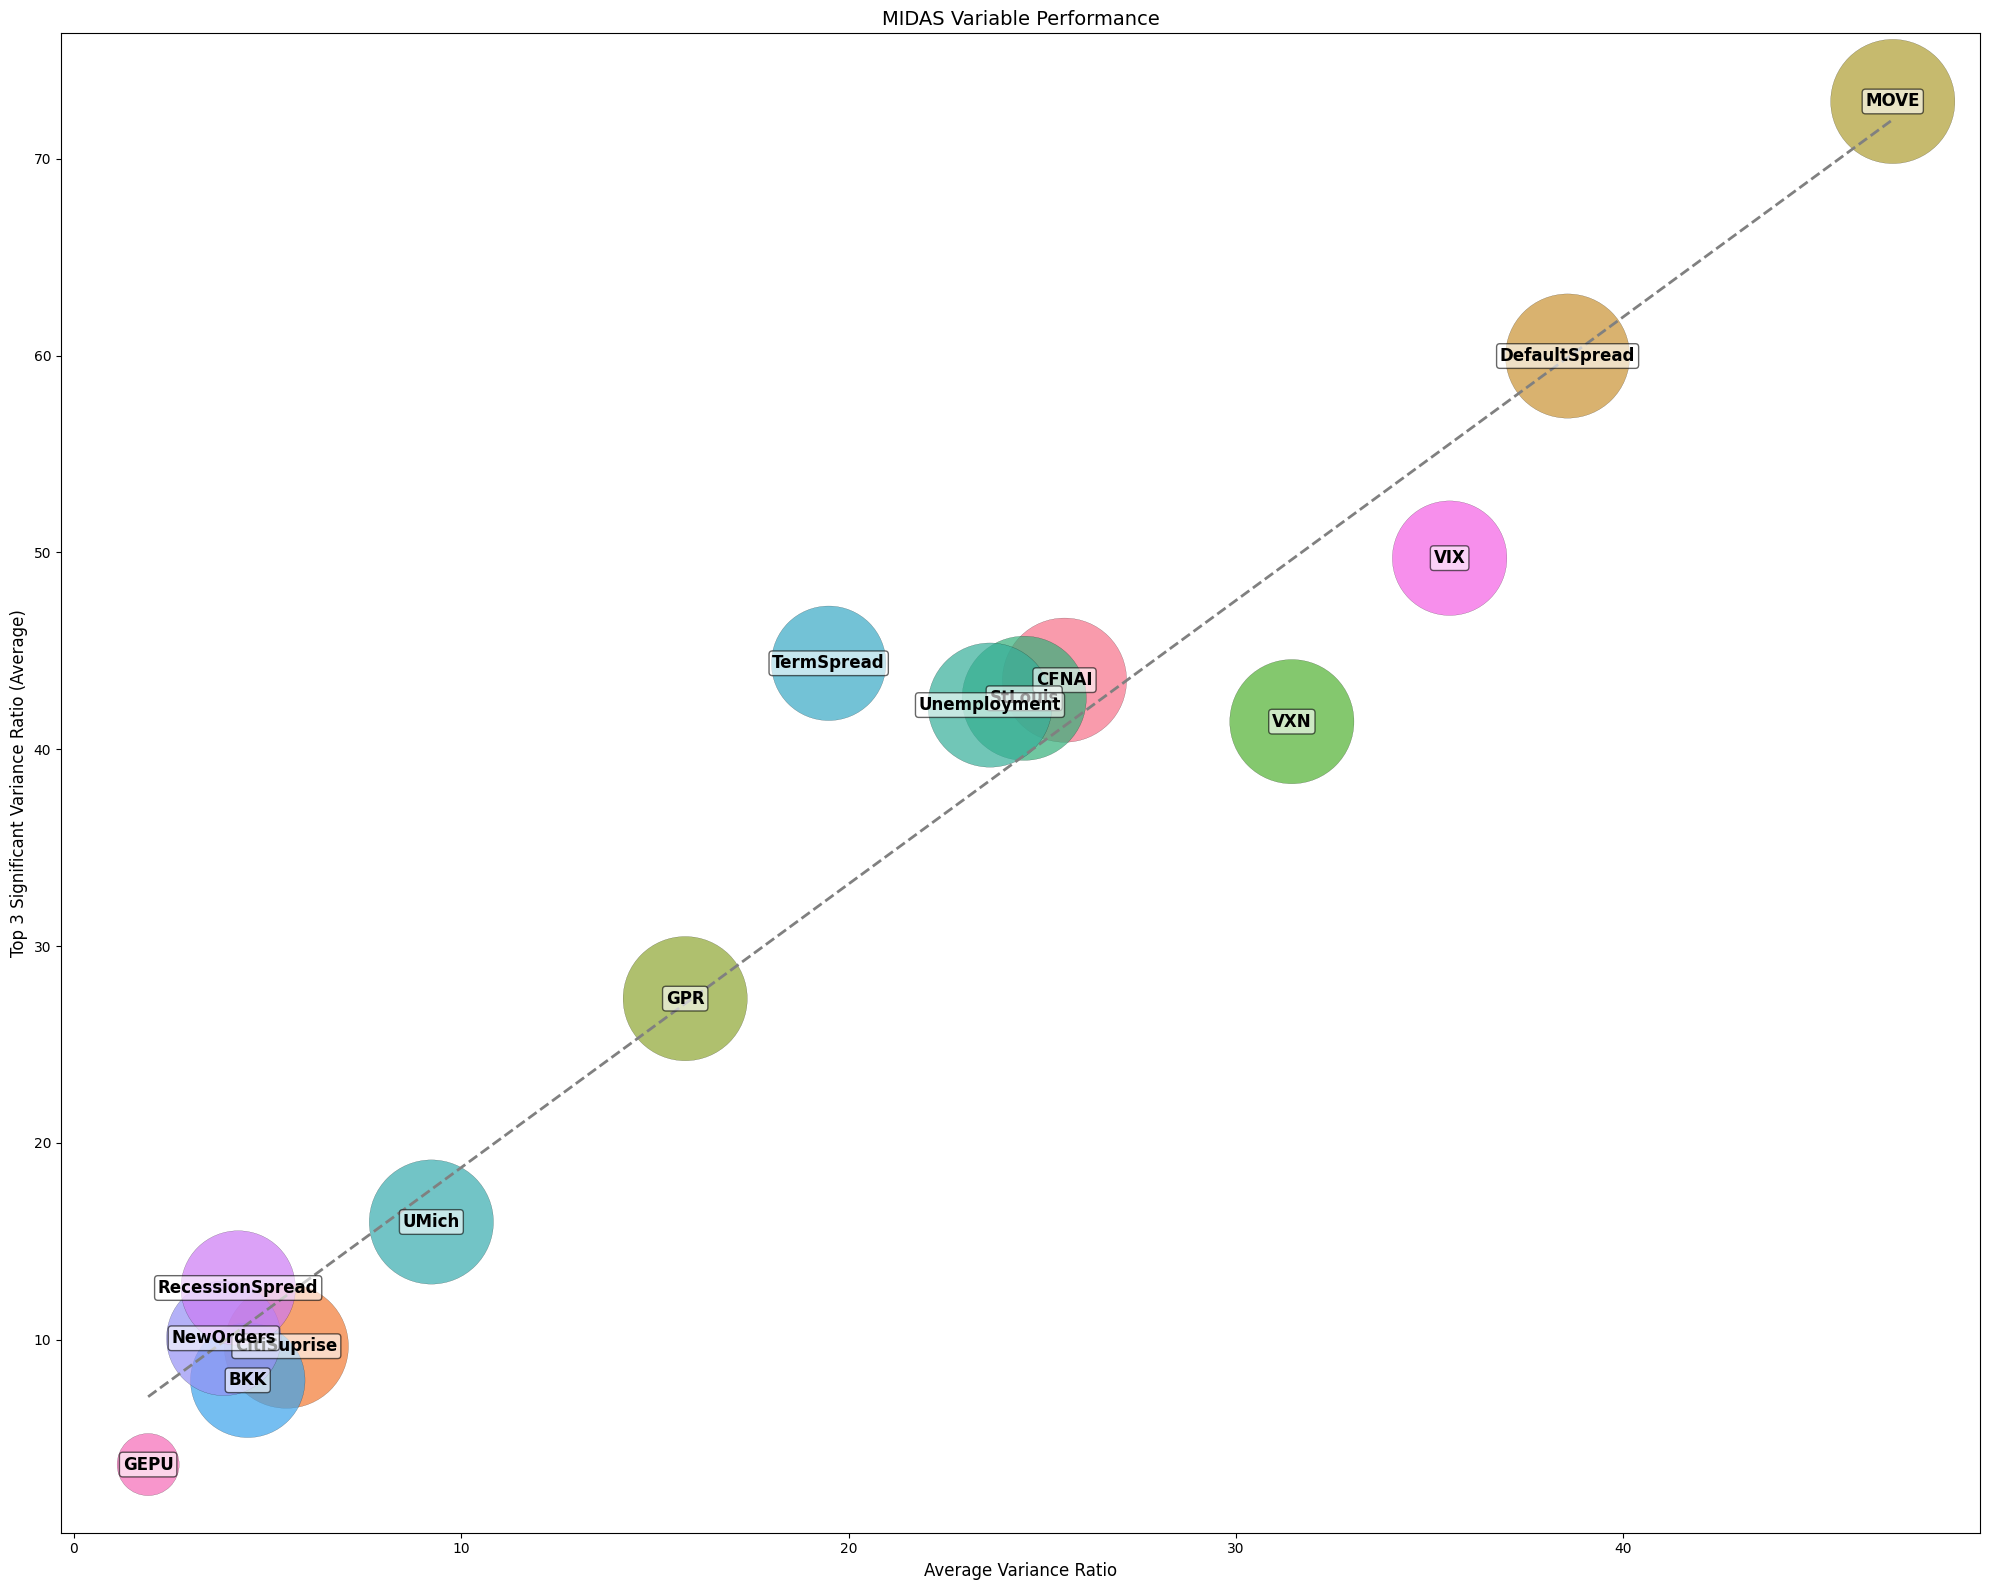

,MIDAS Variable,Significant_Count,Avg_VR,Top3_Avg_VR
1,CFNAI,10,25.574741,43.511510
2,CitiSuprise,10,5.486261,9.658574
3,DefaultSpread,10,38.562176,59.985029
6,MOVE,10,46.956253,72.922712
5,GPR,10,15.782728,27.325245
14,VXN,10,31.443673,41.403482
9,StLouis,10,24.533898,42.590211
12,Unemployment,10,23.650749,42.244914
11,UMich,10,9.229783,15.972098
10,TermSpread,9,19.486507,44.369350


In [408]:
df_Month_Sector_formatted = Reformat_GARCH_Analysis(df_Month_Sector)
visualize_midas_performance(df_Month_Sector_formatted, top_n = 16, drop = True)

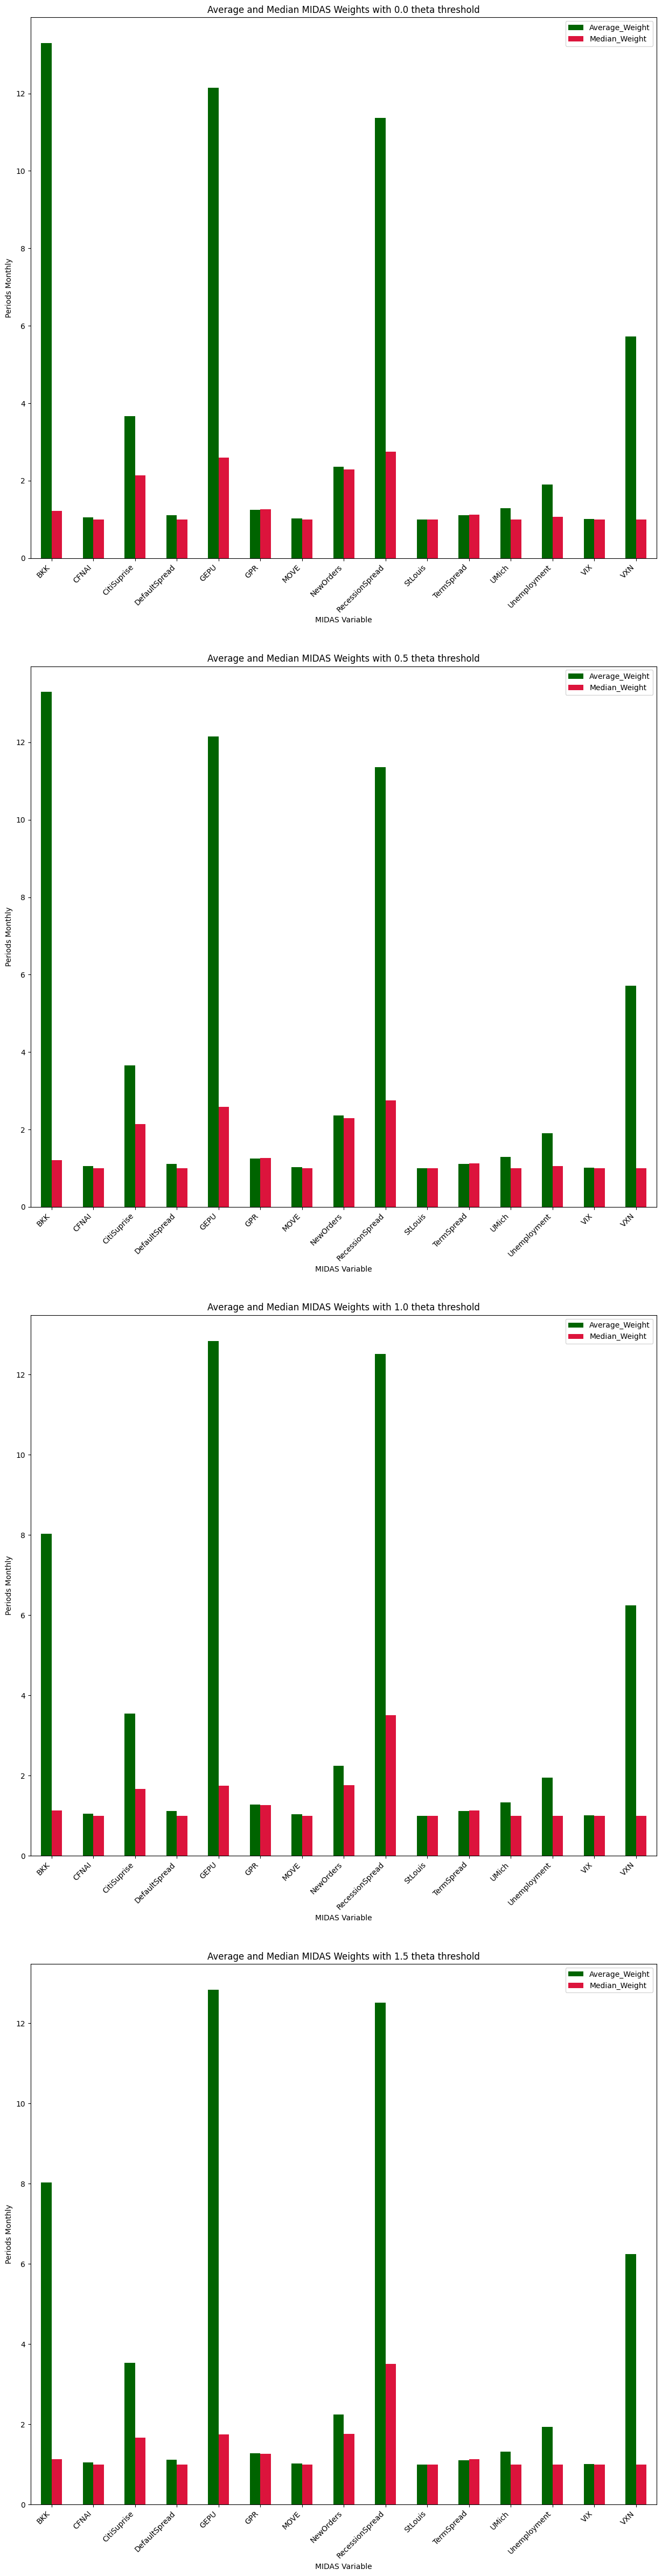

In [407]:
fig, axs = plt.subplots(4, 1, figsize = (15, 60))
thresholds = np.arange(0, 2, 0.5)
axes = axs.flatten()

for count, threshold in enumerate(thresholds):
    plot_average_weights(df_Month_Sector_formatted, axes[count], threshold = threshold, frequency = 'Monthly')


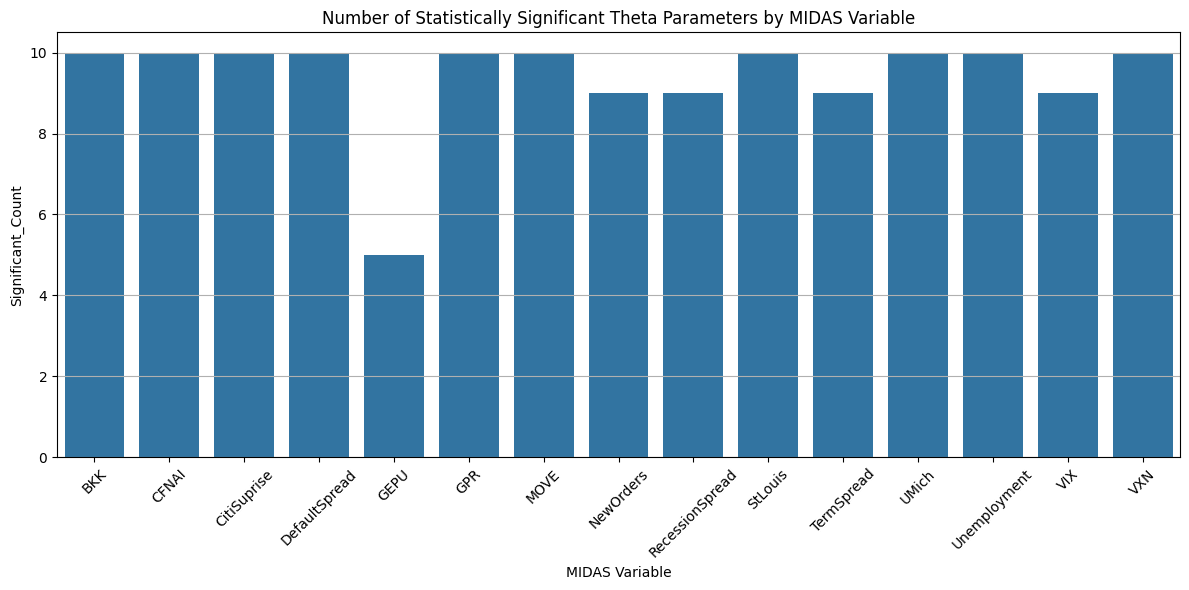

,MIDAS Variable,Significant_Count
0,BKK,10
1,CFNAI,10
2,CitiSuprise,10
3,DefaultSpread,10
4,GEPU,5
5,GPR,10
6,MOVE,10
7,NewOrders,9
8,RecessionSpread,9
9,StLouis,10


In [434]:
plot_significant_counts_bar(df_Month_Sector_formatted)

C:\Users\Phillip\AppData\Local\Temp\ipykernel_11084\556914706.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)


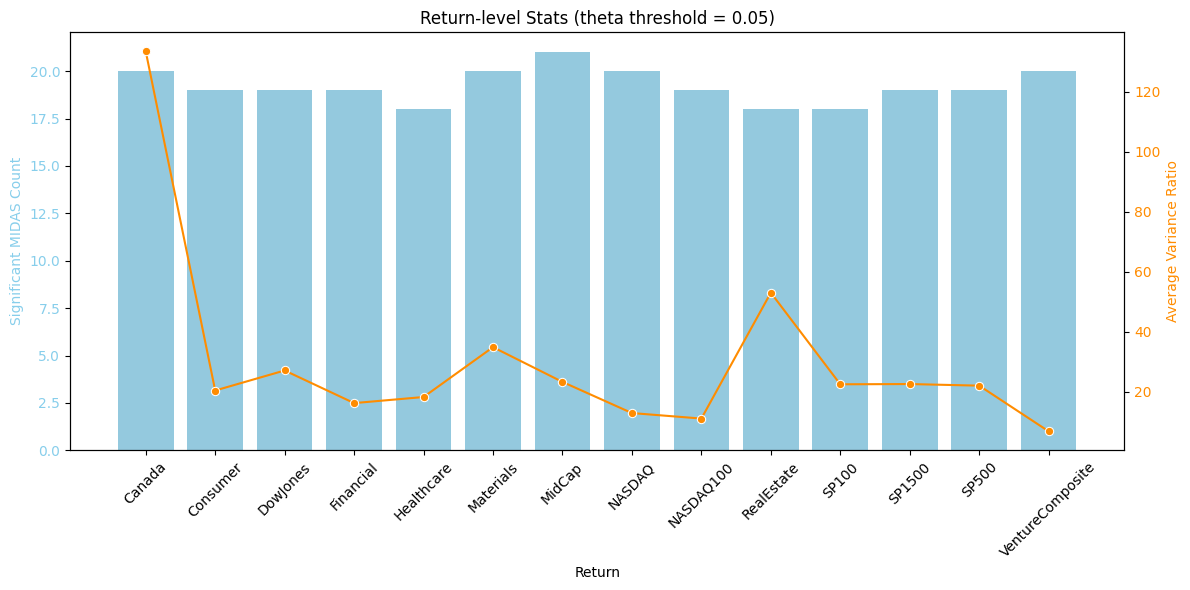

,Return,Significant_Count,Avg_VR
0,Canada,20,133.376680
1,Consumer,19,20.486291
2,DowJones,19,27.155635
3,Financial,19,16.299466
4,Healthcare,18,18.322213
5,Materials,20,34.917313
6,MidCap,21,23.346814
7,NASDAQ,20,12.983575
8,NASDAQ100,19,11.151366
9,RealEstate,18,53.040806


In [435]:
plot_return_level_stats(df)

### Monthly US Indices

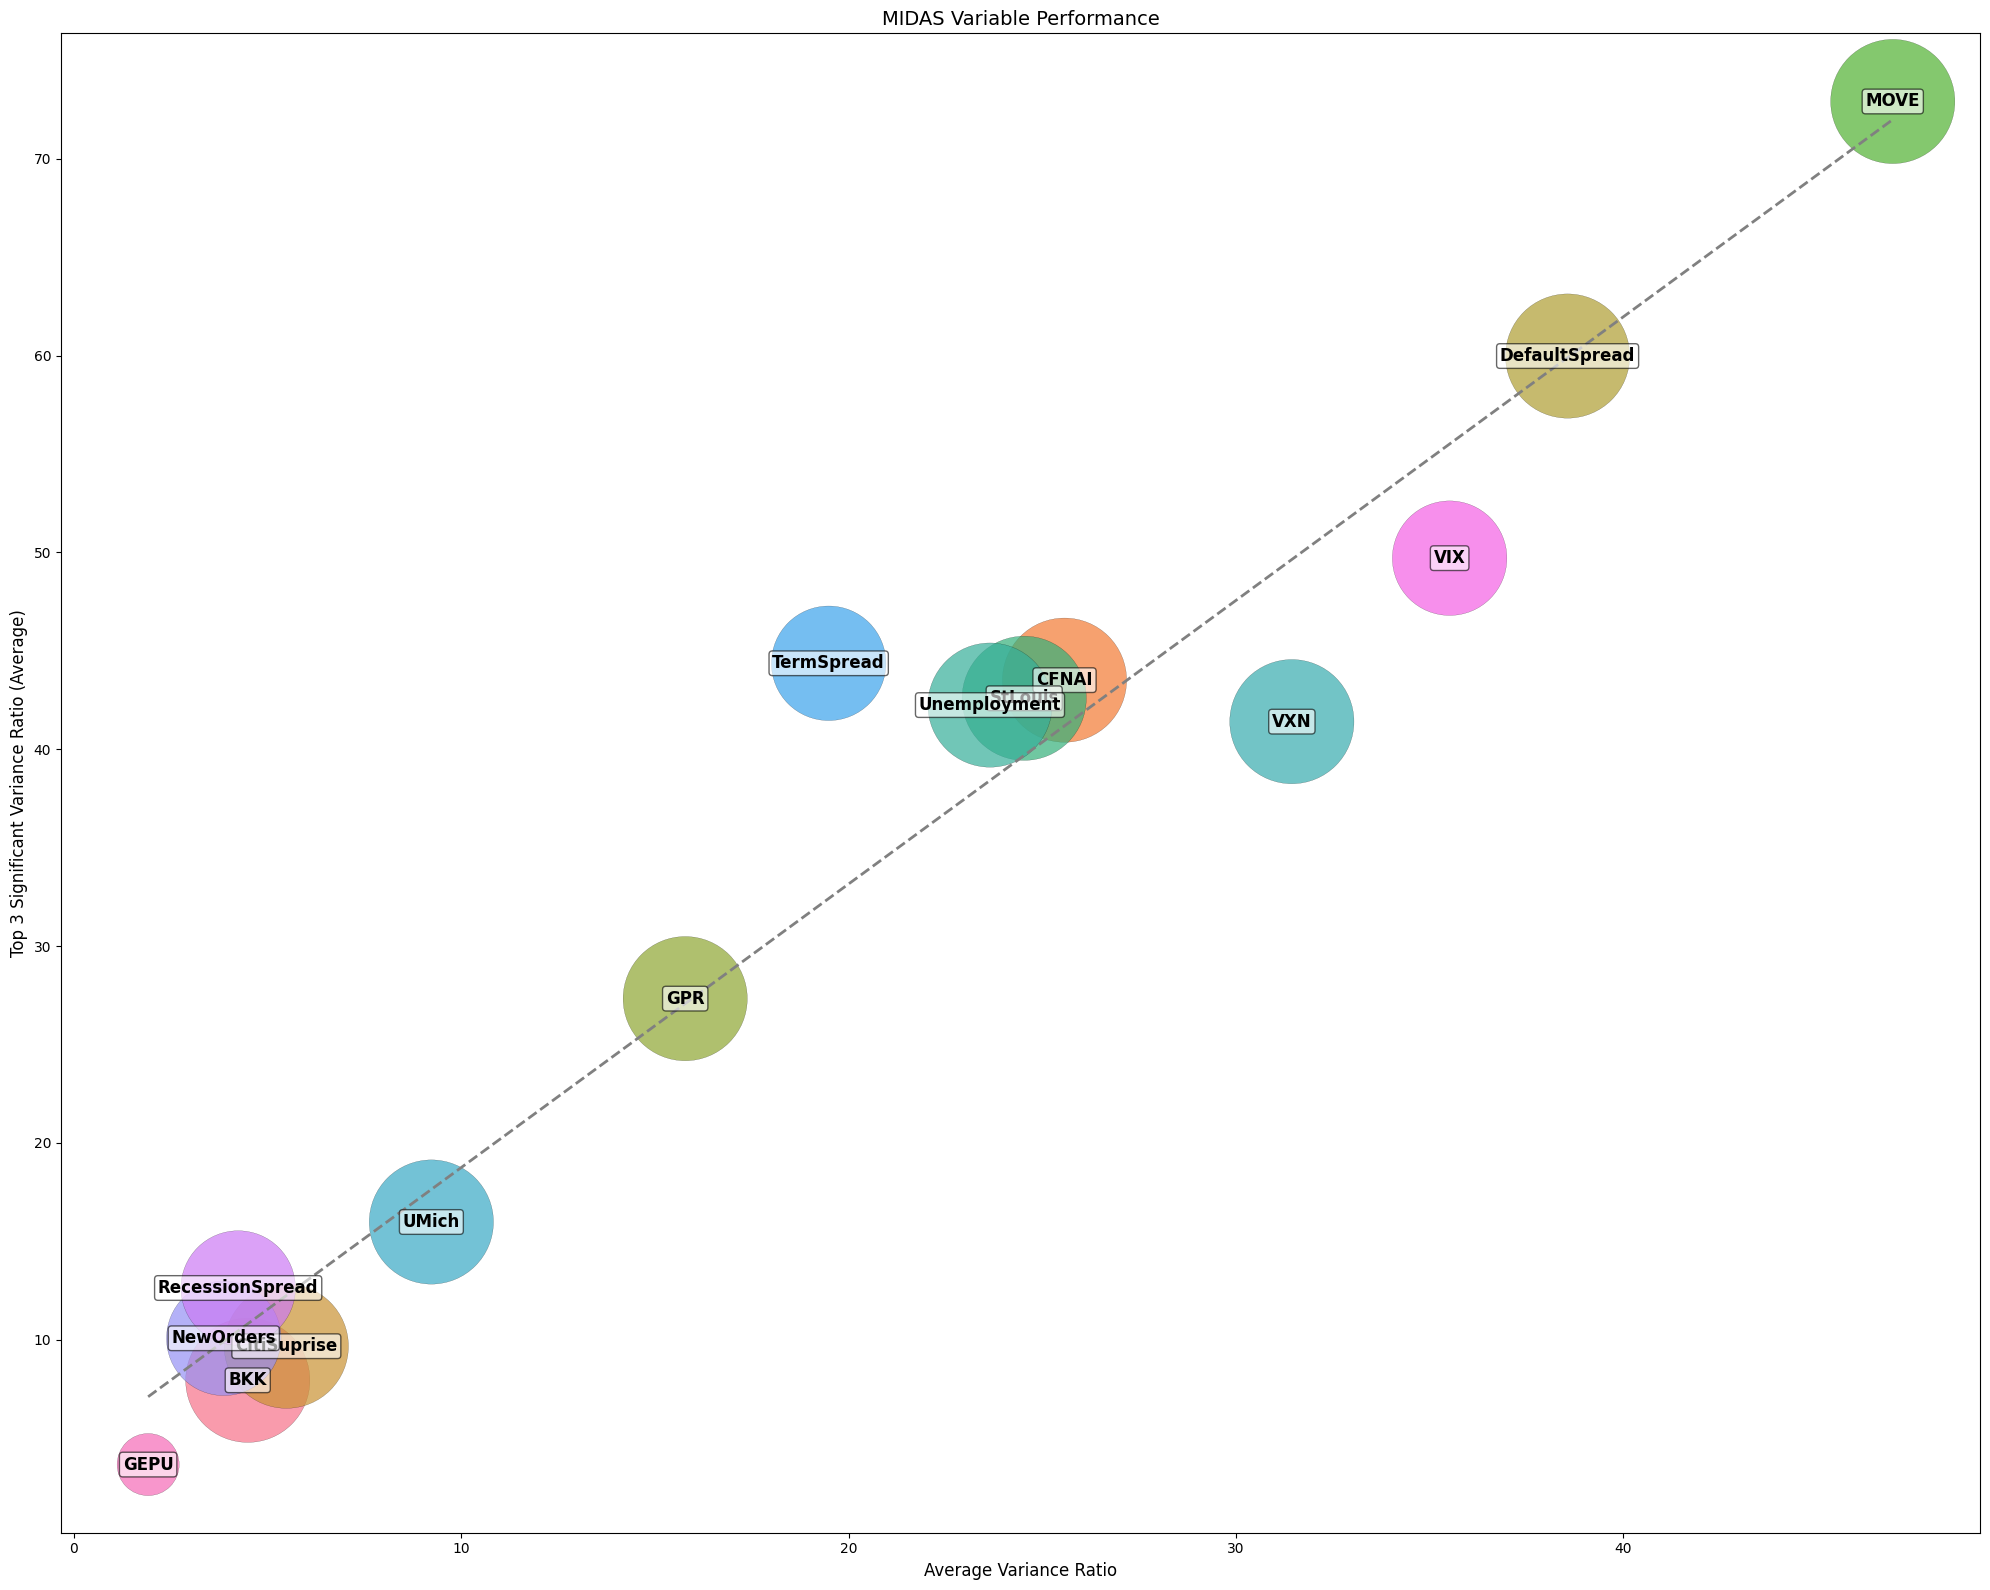

,MIDAS Variable,Significant_Count,Avg_VR,Top3_Avg_VR
0,BKK,10,4.489797,7.926640
1,CFNAI,10,25.574741,43.511510
2,CitiSuprise,10,5.486261,9.658574
3,DefaultSpread,10,38.562176,59.985029
5,GPR,10,15.782728,27.325245
6,MOVE,10,46.956253,72.922712
9,StLouis,10,24.533898,42.590211
12,Unemployment,10,23.650749,42.244914
14,VXN,10,31.443673,41.403482
11,UMich,10,9.229783,15.972098


In [427]:
df_Month_Sector_formatted = Reformat_GARCH_Analysis(df_Month_Sector)
visualize_midas_performance(df_Month_Sector_formatted, top_n = 16, drop = True)

C:\Users\Phillip\AppData\Local\Temp\ipykernel_11084\556914706.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)


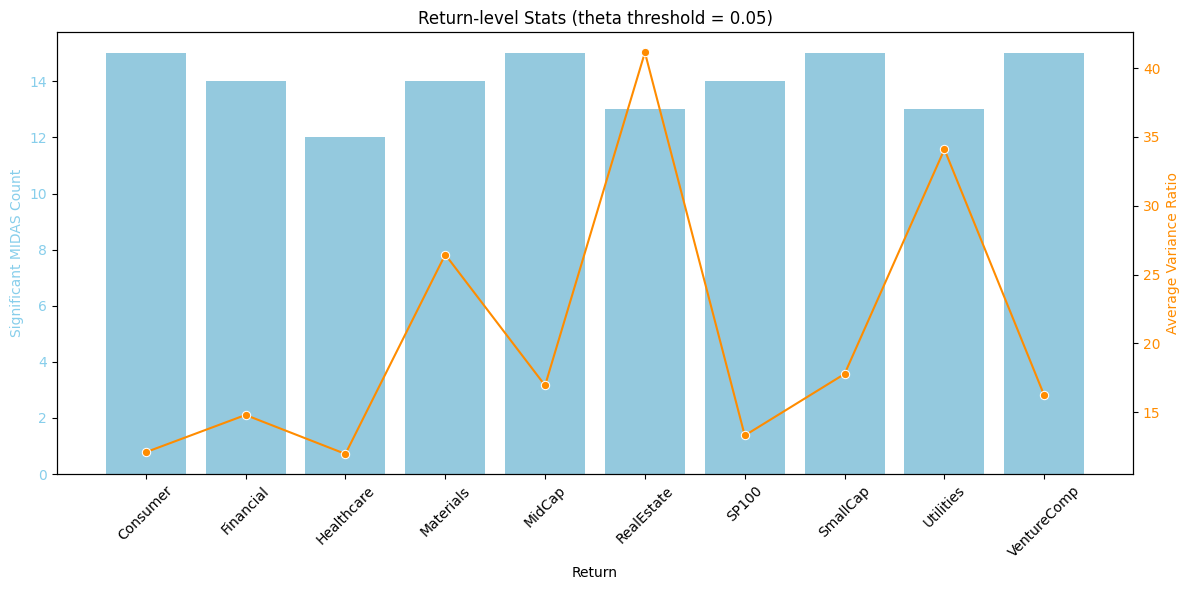

,Return,Significant_Count,Avg_VR
0,Consumer,15,12.101797
1,Financial,14,14.807309
2,Healthcare,12,11.978135
3,Materials,14,26.457272
4,MidCap,15,16.950320
5,RealEstate,13,41.138178
6,SP100,14,13.317653
7,SmallCap,15,17.786900
8,Utilities,13,34.097830
9,VentureComp,15,16.224523


In [430]:
plot_return_level_stats(df_Month_Sector_formatted)